In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

sns.set_theme(style="whitegrid")


In [13]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd

# Load from mounted Google Drive path
df_train = pd.read_csv('/content/drive/MyDrive/colab_dataset/layer_1/combined_dataset.csv')

df_train = df_train.drop_duplicates().reset_index(drop=True)
target_col = "GroundTruth"
feature_cols = [c for c in df_train.columns if not c.startswith('FrameA_') and not c.startswith('FrameB_') and c != 'GroundTruth']
X_train = df_train[feature_cols]
y_train = df_train[target_col]
print(f"Training Dataset shape: {df_train.shape}")
print(f"Training set: {X_train.shape[0]} samples | {len(feature_cols)} features")
print(f"Training Class Balance: {dict(y_train.value_counts())}")


Training Dataset shape: (2090, 120)
Training set: 2090 samples | 59 features
Training Class Balance: {0: np.int64(1139), 1: np.int64(951)}


In [15]:
# ==============================================================================
# Ingest & Validate 3 Separate Domain Test Datasets
# ==============================================================================
base_test_dir = '/content/drive/MyDrive/colab_dataset/layer_1'

# 1. Load CSVs from Google Drive
df_test_coding = pd.read_csv(f'{base_test_dir}/test_coding.csv')
df_test_slides = pd.read_csv(f'{base_test_dir}/test_slides.csv')
df_test_math   = pd.read_csv(f'{base_test_dir}/test_math.csv')

# 2. Clean identical duplicates
df_test_coding = df_test_coding.drop_duplicates().reset_index(drop=True)
df_test_slides = df_test_slides.drop_duplicates().reset_index(drop=True)
df_test_math   = df_test_math.drop_duplicates().reset_index(drop=True)

# 3. Separate features (59 delta features) and target for each domain
X_test_coding = df_test_coding[feature_cols]
y_test_coding = df_test_coding[target_col]

X_test_slides = df_test_slides[feature_cols]
y_test_slides = df_test_slides[target_col]

X_test_math = df_test_math[feature_cols]
y_test_math = df_test_math[target_col]

# 4. Strict assertion: verify feature alignment across all test datasets
for domain_label, X_subset in [('Coding', X_test_coding), ('Slides', X_test_slides), ('Math', X_test_math)]:
    assert list(X_subset.columns) == feature_cols, f"Feature columns mismatch in {domain_label} test set!"

# 5. Default backward-compatibility pointers
X_test = X_test_coding
y_test = y_test_coding

# 6. Structured dictionary for evaluation
test_suites = {
    'Coding': (X_test_coding, y_test_coding),
    'Slides': (X_test_slides, y_test_slides),
    'Math':   (X_test_math, y_test_math)
}

# Display summary statistics
summary_rows = []
for name, (X, y) in test_suites.items():
    counts = dict(y.value_counts())
    summary_rows.append({
        "Domain": name,
        "Samples": len(X),
        "Features": X.shape[1],
        "Class 0 (No Change)": counts.get(0, 0),
        "Class 1 (Visual Change)": counts.get(1, 0),
        "Pos Rate (%)": round(100.0 * counts.get(1, 0) / len(y), 2)
    })

print("==================== TEST DATASETS INGESTION SUMMARY ====================")
print(pd.DataFrame(summary_rows).to_string(index=False))


==================== TEST DATASETS INGESTION SUMMARY ====================
Domain  Samples  Features  Class 0 (No Change)  Class 1 (Visual Change)  Pos Rate (%)
Coding      120        59                   83                       37         30.83
Slides      158        59                  147                       11          6.96
  Math      216        59                   83                      133         61.57


In [16]:
# ==============================================================================
# Modular Multi-Domain Evaluation & Diagnostics Engine
# ==============================================================================
global_benchmark_records = []

def evaluate_and_plot_domain(pipeline, X_test, y_test, domain_name, model_name, threshold=0.5, feature_cols=feature_cols):
    """
    Evaluates a trained pipeline on a specific domain test set:
    - Calculates Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC.
    - Prints formatted metrics and scikit-learn classification report.
    - Generates and saves a 2x2 diagnostic plot (Confusion Matrix, ROC, PR Curve, Feature Importances).
    - Records metrics for global cross-domain benchmarking.
    """
    # Probability and thresholded predictions
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    # Core evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    metrics = {
        "Model": model_name,
        "Domain": domain_name,
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }
    global_benchmark_records.append(metrics)

    print(f"\n{'='*25} {model_name.upper()} - {domain_name.upper()} TEST (T={threshold:.2f}) {'='*25}")
    metrics_df = pd.DataFrame([
        {"Metric": "Accuracy", "Test Score": f"{acc:.4f}"},
        {"Metric": "Precision", "Test Score": f"{prec:.4f}"},
        {"Metric": "Recall", "Test Score": f"{rec:.4f}"},
        {"Metric": "F1-Score", "Test Score": f"{f1:.4f}"},
        {"Metric": "ROC-AUC", "Test Score": f"{roc_auc:.4f}"},
        {"Metric": "PR-AUC (Average Precision)", "Test Score": f"{pr_auc:.4f}"}
    ])
    print(metrics_df.to_string(index=False))
    print(f"\n--- Classification Report: {model_name} [{domain_name}] (T={threshold:.2f}) ---")
    print(classification_report(y_test, y_pred, target_names=["No Change (0)", "Visual Change (1)"], zero_division=0))

    # 2x2 Diagnostic Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0],
                xticklabels=["No Change (0)", "Visual Change (1)"],
                yticklabels=["No Change (0)", "Visual Change (1)"])
    axes[0, 0].set_title(f"{model_name} [{domain_name}] Confusion Matrix (T={threshold:.2f})", fontsize=12, fontweight="bold")
    axes[0, 0].set_xlabel("Predicted")
    axes[0, 0].set_ylabel("Actual")

    # 2. ROC-AUC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0, 1].plot(fpr, tpr, color="#2ecc71", lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
    axes[0, 1].plot([0, 1], [0, 1], color="grey", linestyle="--")
    axes[0, 1].set_title(f"{model_name} [{domain_name}] ROC Curve", fontsize=12, fontweight="bold")
    axes[0, 1].set_xlabel("False Positive Rate")
    axes[0, 1].set_ylabel("True Positive Rate")
    axes[0, 1].legend(loc="lower right")

    # 3. Precision-Recall Curve
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    axes[1, 0].plot(rec_curve, prec_curve, color="#e74c3c", lw=2, label=f"PR Curve (AP = {pr_auc:.4f})")
    axes[1, 0].set_title(f"{model_name} [{domain_name}] Precision-Recall Curve", fontsize=12, fontweight="bold")
    axes[1, 0].set_xlabel("Recall")
    axes[1, 0].set_ylabel("Precision")
    axes[1, 0].legend(loc="lower left")

    # 4. Feature Importance / Coefficients
    clf = pipeline.named_steps["classifier"]
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
        imp_title = f"{model_name} Top 10 Feature Importances"
        imp_df = pd.DataFrame({"Feature": feature_cols, "Importance": importances})
    elif hasattr(clf, "coef_"):
        importances = np.abs(clf.coef_[0])
        imp_title = f"{model_name} Top 10 Coefficients (|Weight|)"
        imp_df = pd.DataFrame({"Feature": feature_cols, "Importance": importances})
    else:
        importances = np.zeros(len(feature_cols))
        imp_title = f"{model_name} Features"
        imp_df = pd.DataFrame({"Feature": feature_cols, "Importance": importances})

    top_imp = imp_df.sort_values(by="Importance", ascending=False).head(10)
    sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")
    axes[1, 1].set_title(imp_title, fontsize=12, fontweight="bold")
    axes[1, 1].set_xlabel("Importance Magnitude")

    plt.tight_layout()
    safe_name = f"{model_name}_{domain_name}_diagnostics.png".lower().replace(" ", "_")
    plt.savefig(safe_name, dpi=300)
    plt.show()

    return metrics

def summarize_domain_metrics(metrics_list):
    df_sum = pd.DataFrame(metrics_list)
    return df_sum[["Model", "Domain", "Threshold", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]]


## 1. Logistic Regression Classifier (Delta Features)


In [17]:
# ==============================================================================
# Model 1: Logistic Regression - Training on Combined Dataset
# ==============================================================================
logreg_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

# Fit on combined training data
logreg_pipeline.fit(X_train, y_train)
print("Logistic Regression Model Training Complete.")


Logistic Regression Model Training Complete.



========================= LOGISTIC REGRESSION - CODING TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.7833
                 Precision     0.5902
                    Recall     0.9730
                  F1-Score     0.7347
                   ROC-AUC     0.9131
PR-AUC (Average Precision)     0.8120

--- Classification Report: Logistic Regression [Coding] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       0.98      0.70      0.82        83
Visual Change (1)       0.59      0.97      0.73        37

         accuracy                           0.78       120
        macro avg       0.79      0.84      0.78       120
     weighted avg       0.86      0.78      0.79       120



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


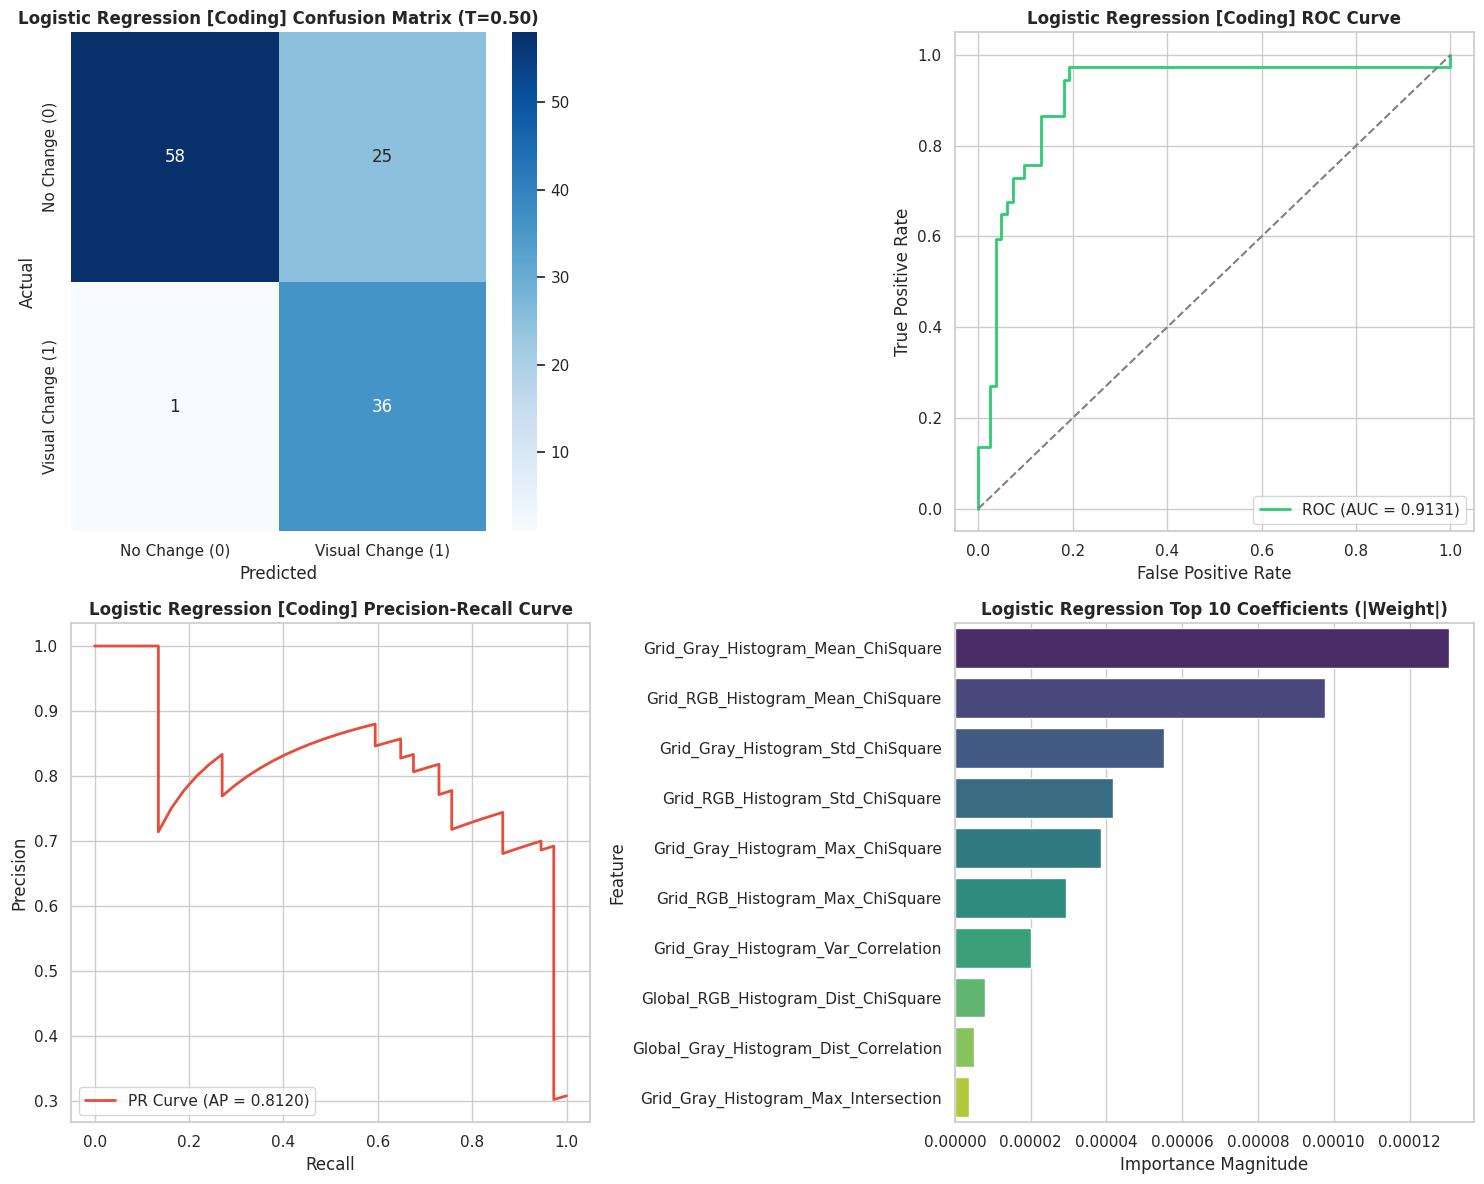

In [18]:
# --- Logistic Regression: Evaluation on Domain 1 (Coding Session) ---
metrics_logreg_coding = evaluate_and_plot_domain(
    pipeline=logreg_pipeline,
    X_test=X_test_coding,
    y_test=y_test_coding,
    domain_name="Coding",
    model_name="Logistic Regression",
    threshold=0.50
)



========================= LOGISTIC REGRESSION - SLIDES TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.7532
                 Precision     0.2200
                    Recall     1.0000
                  F1-Score     0.3607
                   ROC-AUC     1.0000
PR-AUC (Average Precision)     1.0000

--- Classification Report: Logistic Regression [Slides] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       1.00      0.73      0.85       147
Visual Change (1)       0.22      1.00      0.36        11

         accuracy                           0.75       158
        macro avg       0.61      0.87      0.60       158
     weighted avg       0.95      0.75      0.81       158



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


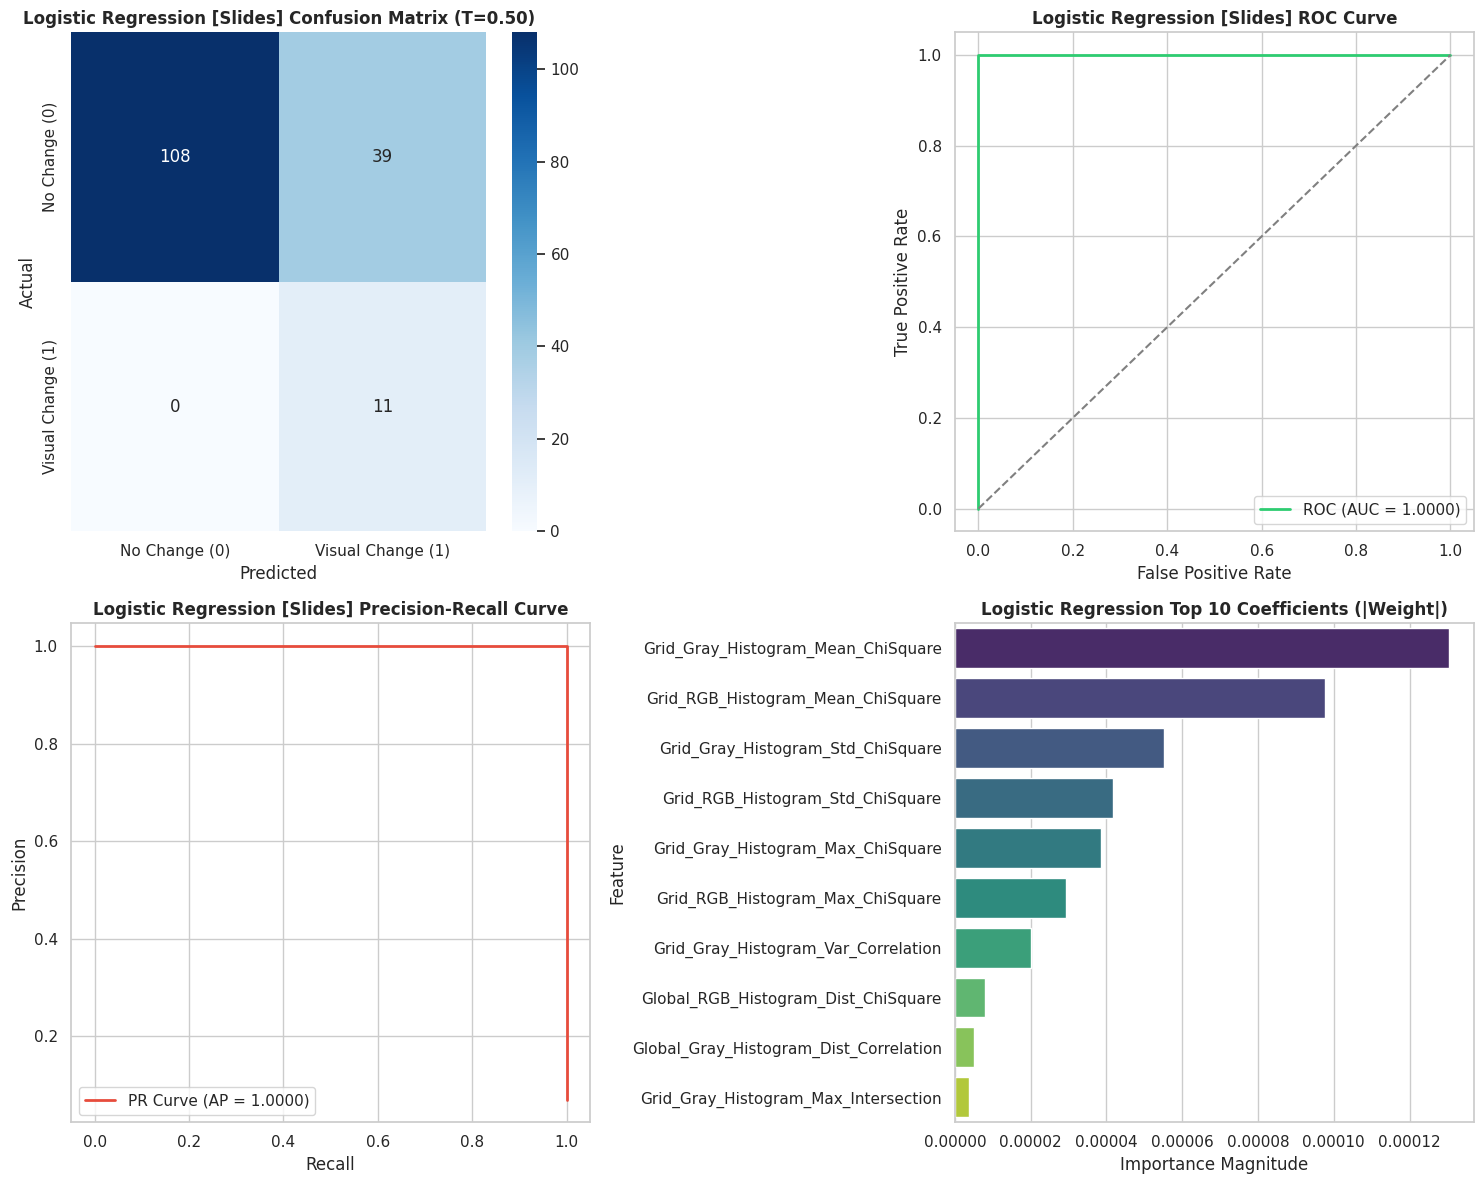

In [19]:
# --- Logistic Regression: Evaluation on Domain 2 (Slide Presentation) ---
metrics_logreg_slides = evaluate_and_plot_domain(
    pipeline=logreg_pipeline,
    X_test=X_test_slides,
    y_test=y_test_slides,
    domain_name="Slides",
    model_name="Logistic Regression",
    threshold=0.50
)



========================= LOGISTIC REGRESSION - MATH TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.7731
                 Precision     0.8684
                    Recall     0.7444
                  F1-Score     0.8016
                   ROC-AUC     0.8829
PR-AUC (Average Precision)     0.9258

--- Classification Report: Logistic Regression [Math] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       0.67      0.82      0.74        83
Visual Change (1)       0.87      0.74      0.80       133

         accuracy                           0.77       216
        macro avg       0.77      0.78      0.77       216
     weighted avg       0.79      0.77      0.78       216



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


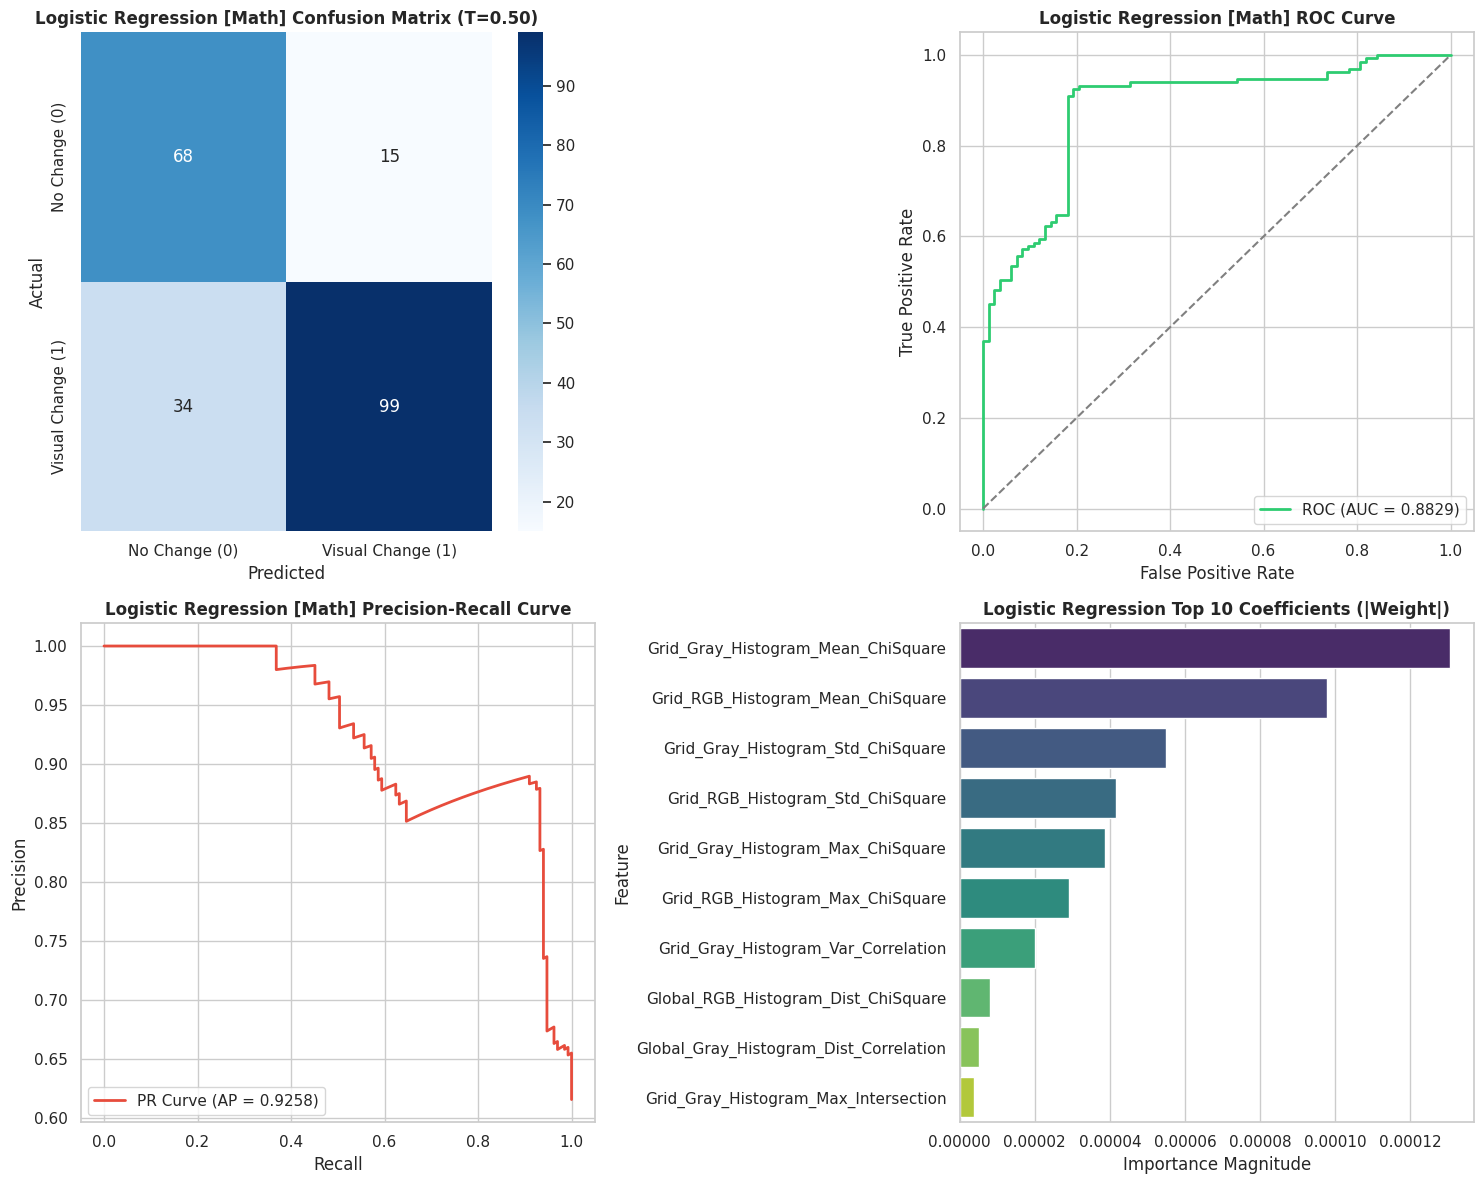

In [20]:
# --- Logistic Regression: Evaluation on Domain 3 (Math Lecture) ---
metrics_logreg_math = evaluate_and_plot_domain(
    pipeline=logreg_pipeline,
    X_test=X_test_math,
    y_test=y_test_math,
    domain_name="Math",
    model_name="Logistic Regression",
    threshold=0.50
)


In [21]:
# --- Logistic Regression: Cross-Domain Summary & Export ---
df_logreg_summary = summarize_domain_metrics([metrics_logreg_coding, metrics_logreg_slides, metrics_logreg_math])
print("================== LOGISTIC REGRESSION CROSS-DOMAIN SUMMARY ==================")
print(df_logreg_summary.to_string(index=False))

# Export model package with cross-domain metrics
export_package = {
    "model_name": "Logistic Regression (Layer 1 - Combined)",
    "pipeline": logreg_pipeline,
    "feature_columns": feature_cols,
    "cross_domain_metrics": df_logreg_summary.to_dict(orient="records")
}
import os
os.makedirs("L1_models", exist_ok=True)
joblib.dump(export_package, "L1_models/combined_logreg.pkl")
print("Saved model package to 'L1_models/combined_logreg.pkl'")


================== LOGISTIC REGRESSION CROSS-DOMAIN SUMMARY ==================
              Model Domain  Threshold  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
Logistic Regression Coding        0.5  0.783333   0.590164 0.972973  0.734694 0.913058 0.811990
Logistic Regression Slides        0.5  0.753165   0.220000 1.000000  0.360656 1.000000 1.000000
Logistic Regression   Math        0.5  0.773148   0.868421 0.744361  0.801619 0.882870 0.925798
Saved model package to 'L1_models/combined_logreg.pkl'


## 2. Random Forest Classifier (Delta Features)


In [22]:
# ==============================================================================
# Model 2: Random Forest Classifier - Training on Combined Dataset
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest Model Training Complete.")


Random Forest Model Training Complete.



========================= RANDOM FOREST - CODING TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.9583
                 Precision     0.8810
                    Recall     1.0000
                  F1-Score     0.9367
                   ROC-AUC     0.9923
PR-AUC (Average Precision)     0.9801

--- Classification Report: Random Forest [Coding] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       1.00      0.94      0.97        83
Visual Change (1)       0.88      1.00      0.94        37

         accuracy                           0.96       120
        macro avg       0.94      0.97      0.95       120
     weighted avg       0.96      0.96      0.96       120



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


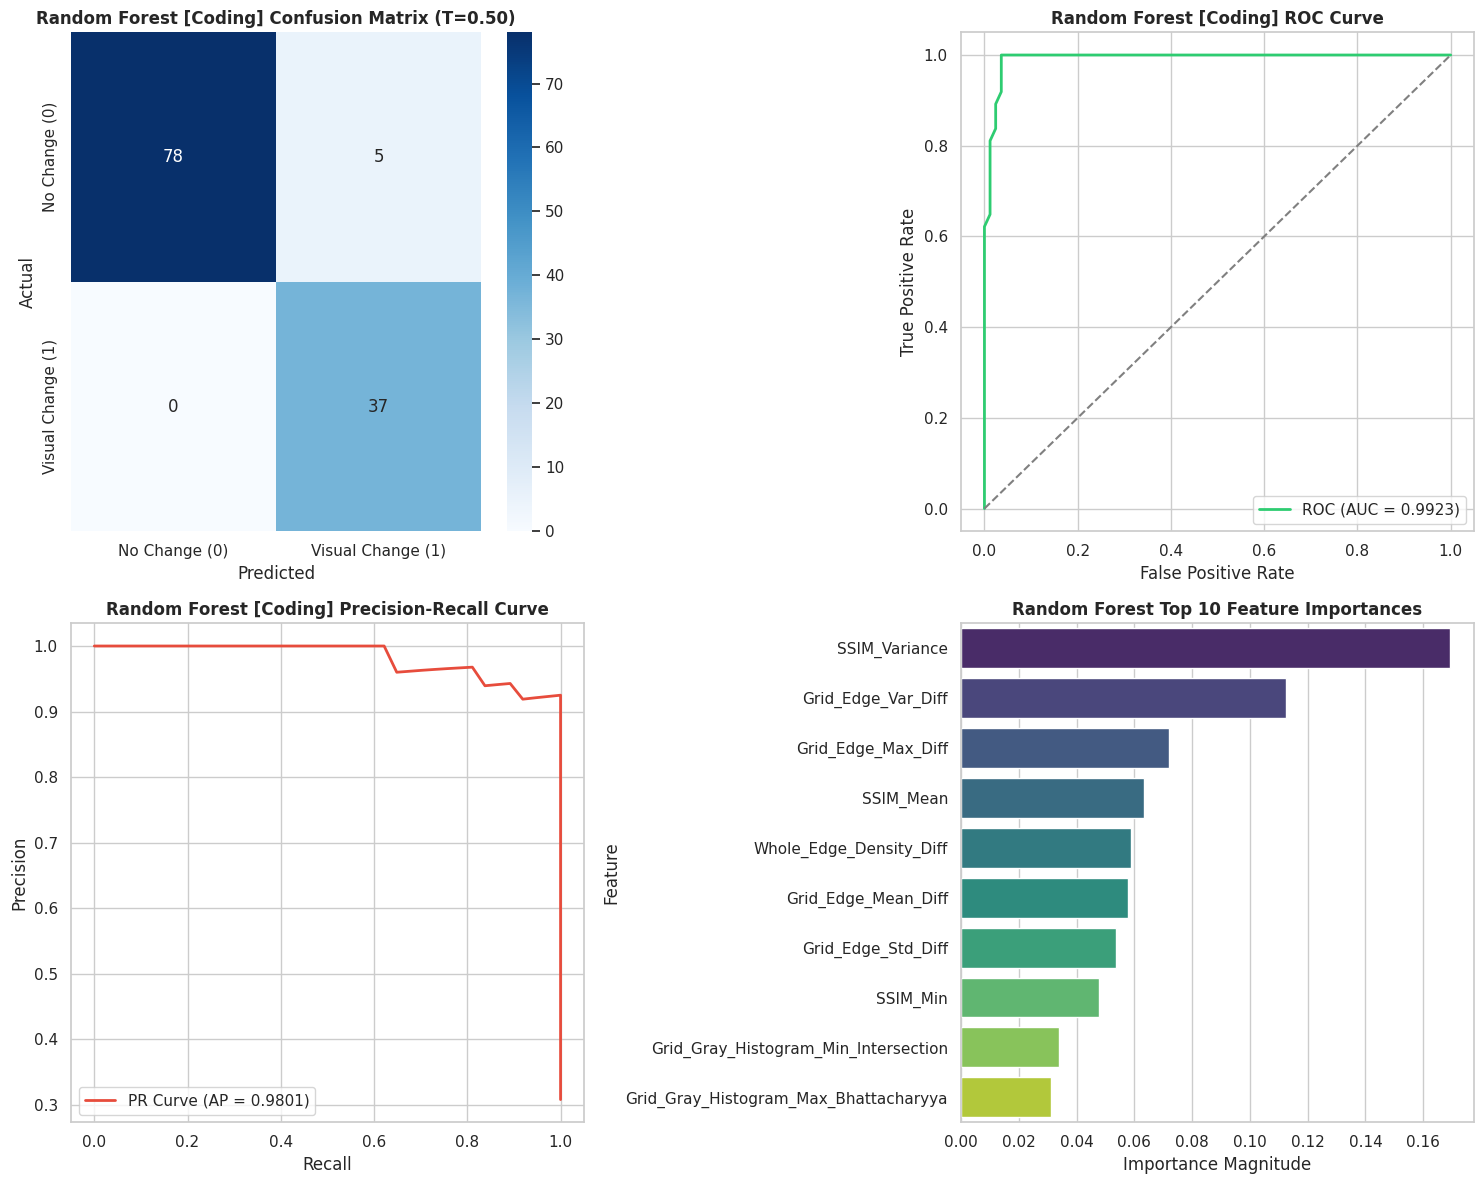

In [23]:
# --- Random Forest: Evaluation on Domain 1 (Coding Session) ---
metrics_rf_coding = evaluate_and_plot_domain(
    pipeline=rf_pipeline,
    X_test=X_test_coding,
    y_test=y_test_coding,
    domain_name="Coding",
    model_name="Random Forest",
    threshold=0.50
)



========================= RANDOM FOREST - SLIDES TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.9810
                 Precision     0.7857
                    Recall     1.0000
                  F1-Score     0.8800
                   ROC-AUC     1.0000
PR-AUC (Average Precision)     1.0000

--- Classification Report: Random Forest [Slides] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       1.00      0.98      0.99       147
Visual Change (1)       0.79      1.00      0.88        11

         accuracy                           0.98       158
        macro avg       0.89      0.99      0.93       158
     weighted avg       0.99      0.98      0.98       158



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


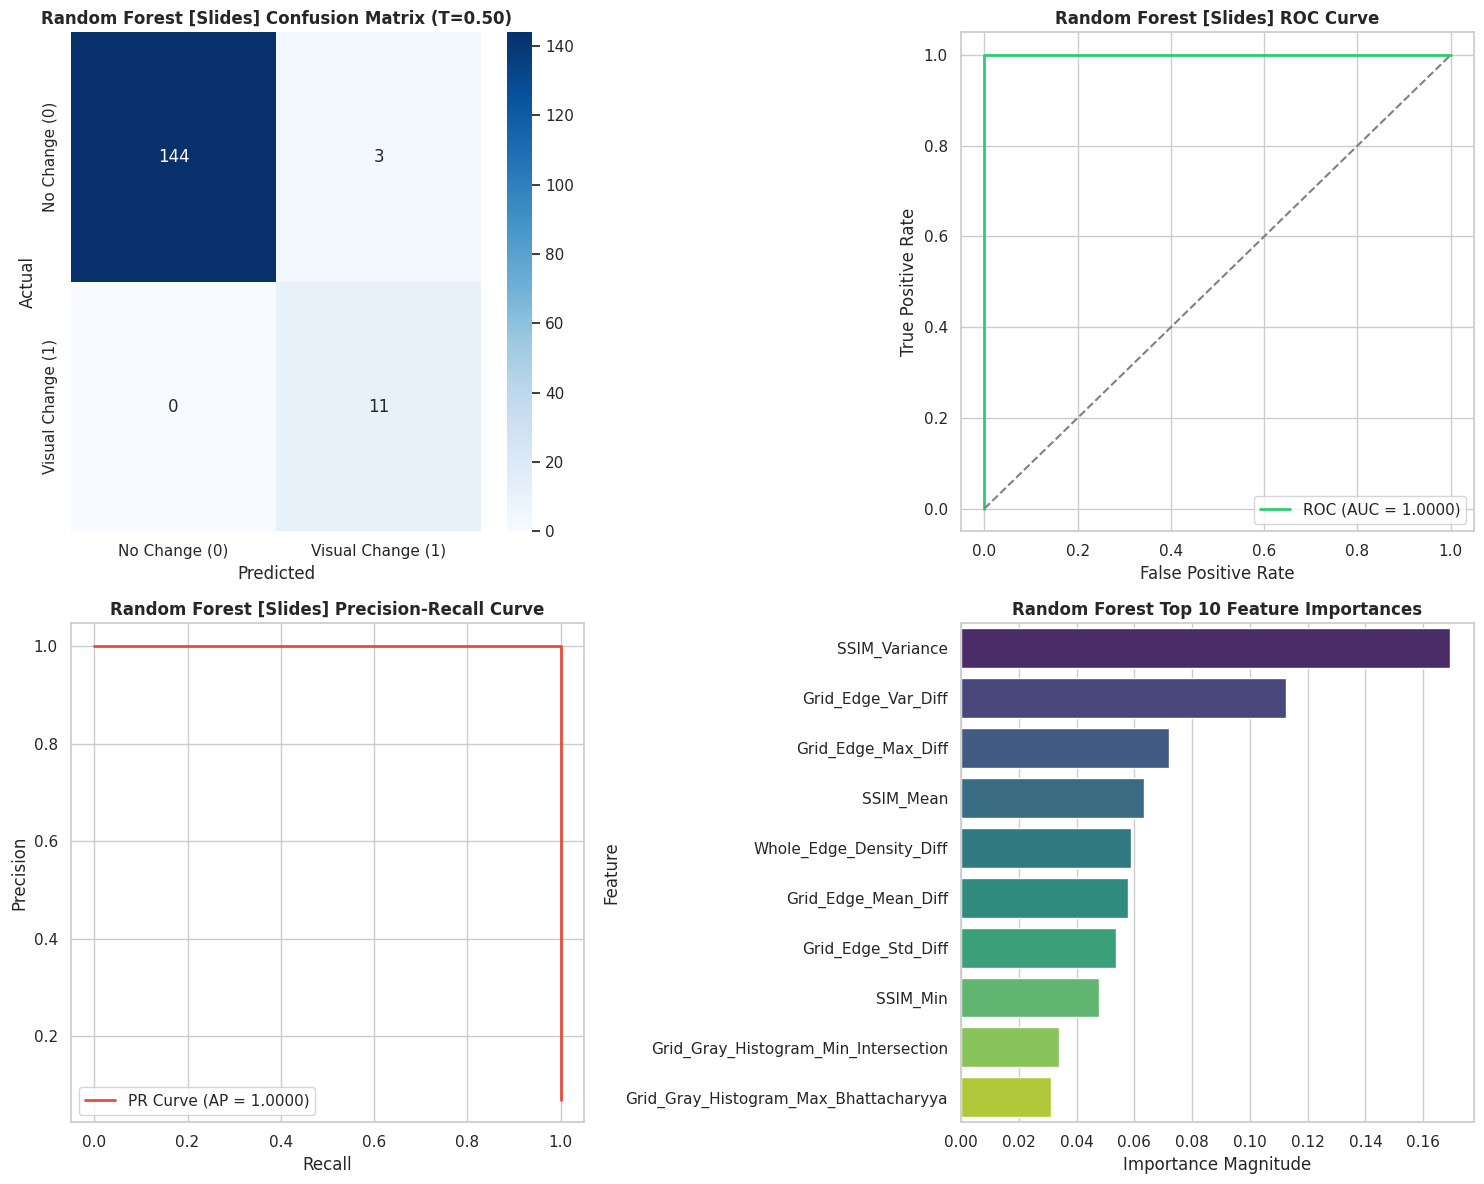

In [24]:
# --- Random Forest: Evaluation on Domain 2 (Slide Presentation) ---
metrics_rf_slides = evaluate_and_plot_domain(
    pipeline=rf_pipeline,
    X_test=X_test_slides,
    y_test=y_test_slides,
    domain_name="Slides",
    model_name="Random Forest",
    threshold=0.50
)



========================= RANDOM FOREST - MATH TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.9167
                 Precision     0.9600
                    Recall     0.9023
                  F1-Score     0.9302
                   ROC-AUC     0.9616
PR-AUC (Average Precision)     0.9673

--- Classification Report: Random Forest [Math] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       0.86      0.94      0.90        83
Visual Change (1)       0.96      0.90      0.93       133

         accuracy                           0.92       216
        macro avg       0.91      0.92      0.91       216
     weighted avg       0.92      0.92      0.92       216



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


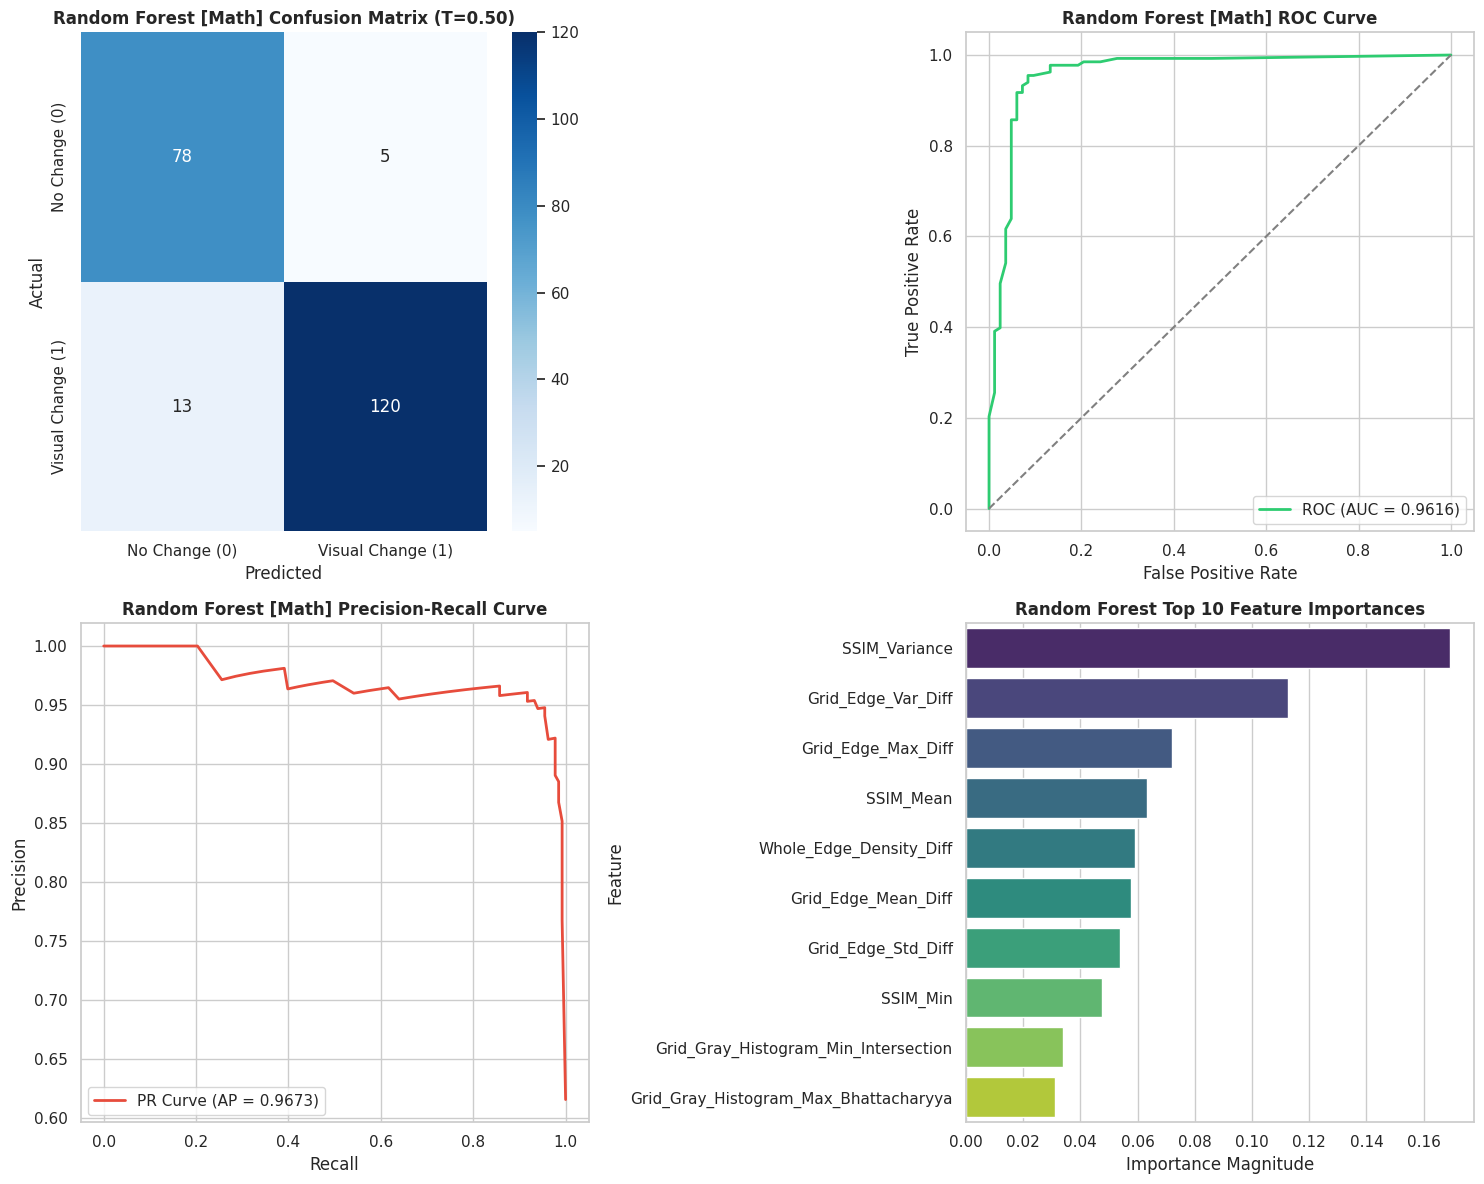

In [25]:
# --- Random Forest: Evaluation on Domain 3 (Math Lecture) ---
metrics_rf_math = evaluate_and_plot_domain(
    pipeline=rf_pipeline,
    X_test=X_test_math,
    y_test=y_test_math,
    domain_name="Math",
    model_name="Random Forest",
    threshold=0.50
)


In [26]:
# --- Random Forest: Cross-Domain Summary & Export ---
df_rf_summary = summarize_domain_metrics([metrics_rf_coding, metrics_rf_slides, metrics_rf_math])
print("================== RANDOM FOREST CROSS-DOMAIN SUMMARY ==================")
print(df_rf_summary.to_string(index=False))

export_package_rf = {
    "model_name": "Random Forest (Layer 1 - Combined)",
    "pipeline": rf_pipeline,
    "feature_columns": feature_cols,
    "cross_domain_metrics": df_rf_summary.to_dict(orient="records")
}
joblib.dump(export_package_rf, "L1_models/combined_random_forest.pkl")
print("Saved model package to 'L1_models/combined_random_forest.pkl'")


================== RANDOM FOREST CROSS-DOMAIN SUMMARY ==================
        Model Domain  Threshold  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
Random Forest Coding        0.5  0.958333   0.880952 1.000000  0.936709 0.992348 0.980125
Random Forest Slides        0.5  0.981013   0.785714 1.000000  0.880000 1.000000 1.000000
Random Forest   Math        0.5  0.916667   0.960000 0.902256  0.930233 0.961591 0.967251
Saved model package to 'L1_models/combined_random_forest.pkl'


In [27]:
%pip install xgboost


## 3. XGBoost Classifier (Delta Features)


In [28]:
# ==============================================================================
# Model 3: XGBoost Classifier - Training on Combined Dataset
# ==============================================================================
from xgboost import XGBClassifier

scale_weight = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("classifier", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        scale_pos_weight=scale_weight
    ))
])

xgb_pipeline.fit(X_train, y_train)
print("XGBoost Model Training Complete.")


XGBoost Model Training Complete.



========================= XGBOOST - CODING TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.9500
                 Precision     0.8605
                    Recall     1.0000
                  F1-Score     0.9250
                   ROC-AUC     0.9945
PR-AUC (Average Precision)     0.9879

--- Classification Report: XGBoost [Coding] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       1.00      0.93      0.96        83
Visual Change (1)       0.86      1.00      0.93        37

         accuracy                           0.95       120
        macro avg       0.93      0.96      0.94       120
     weighted avg       0.96      0.95      0.95       120



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


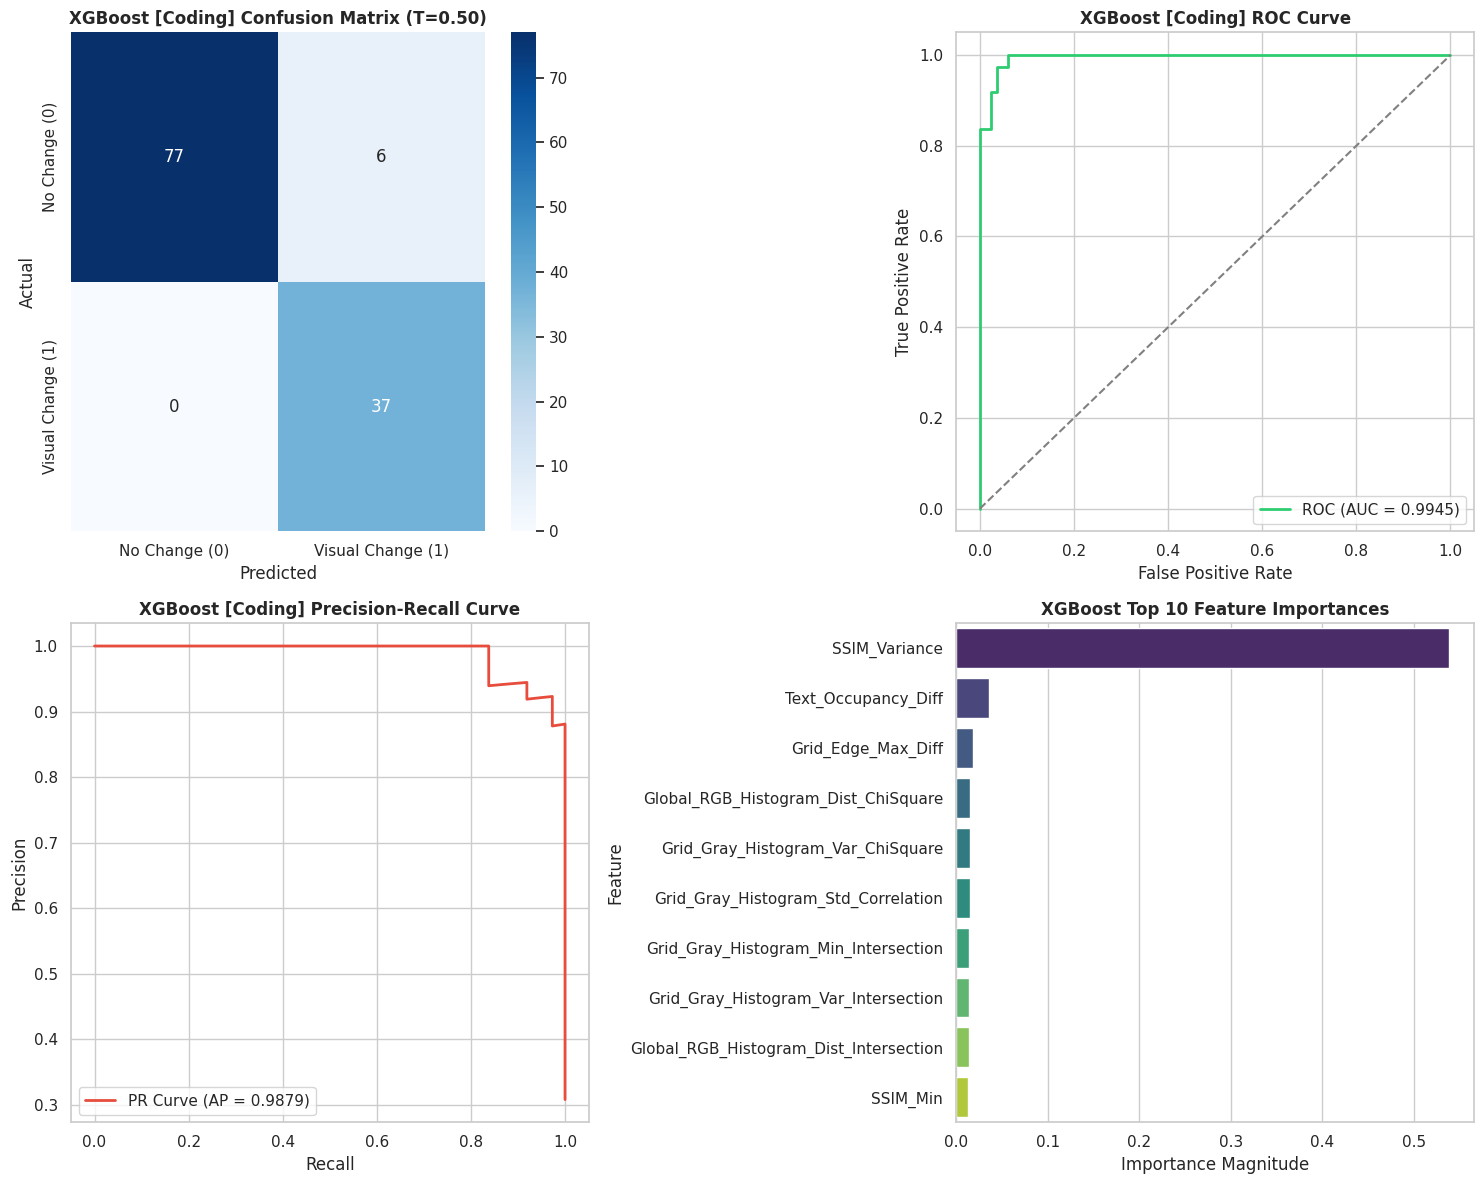

In [29]:
# --- XGBoost: Evaluation on Domain 1 (Coding Session) ---
metrics_xgb_coding = evaluate_and_plot_domain(
    pipeline=xgb_pipeline,
    X_test=X_test_coding,
    y_test=y_test_coding,
    domain_name="Coding",
    model_name="XGBoost",
    threshold=0.50
)



========================= XGBOOST - SLIDES TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.9810
                 Precision     0.7857
                    Recall     1.0000
                  F1-Score     0.8800
                   ROC-AUC     0.9994
PR-AUC (Average Precision)     0.9924

--- Classification Report: XGBoost [Slides] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       1.00      0.98      0.99       147
Visual Change (1)       0.79      1.00      0.88        11

         accuracy                           0.98       158
        macro avg       0.89      0.99      0.93       158
     weighted avg       0.99      0.98      0.98       158



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


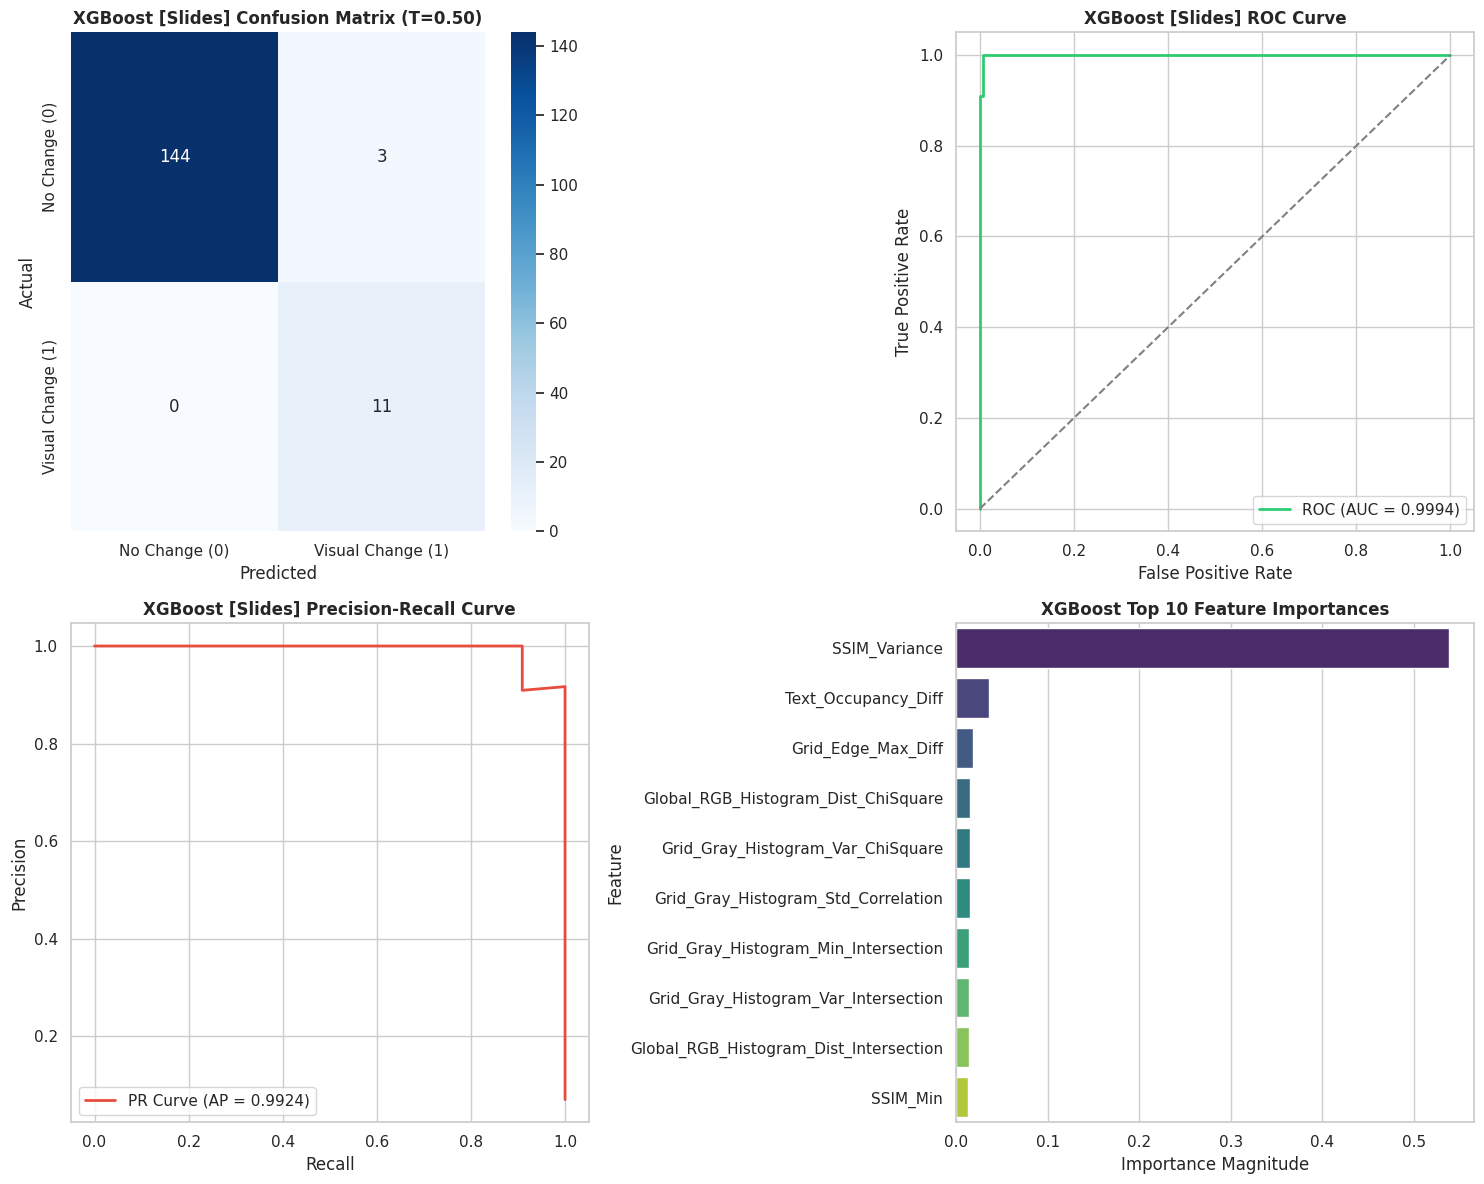

In [30]:
# --- XGBoost: Evaluation on Domain 2 (Slide Presentation) ---
metrics_xgb_slides = evaluate_and_plot_domain(
    pipeline=xgb_pipeline,
    X_test=X_test_slides,
    y_test=y_test_slides,
    domain_name="Slides",
    model_name="XGBoost",
    threshold=0.50
)



========================= XGBOOST - MATH TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.8981
                 Precision     0.9512
                    Recall     0.8797
                  F1-Score     0.9141
                   ROC-AUC     0.9633
PR-AUC (Average Precision)     0.9656

--- Classification Report: XGBoost [Math] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       0.83      0.93      0.88        83
Visual Change (1)       0.95      0.88      0.91       133

         accuracy                           0.90       216
        macro avg       0.89      0.90      0.89       216
     weighted avg       0.90      0.90      0.90       216



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


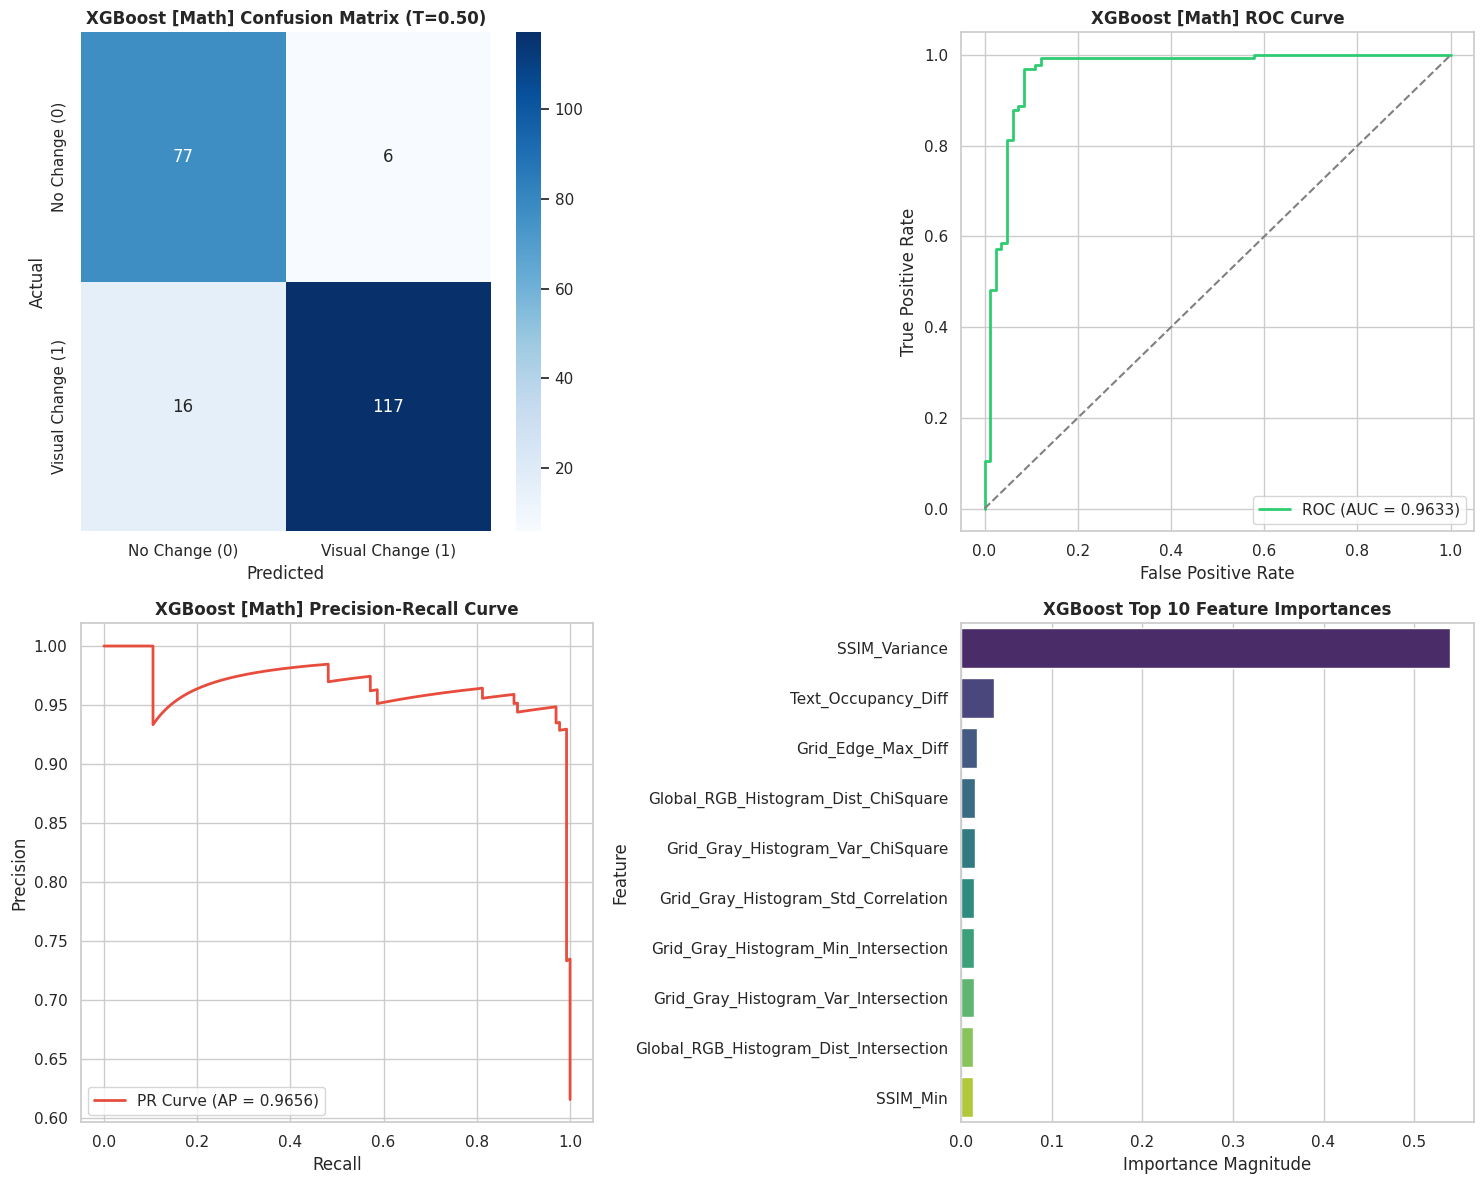

In [31]:
# --- XGBoost: Evaluation on Domain 3 (Math Lecture) ---
metrics_xgb_math = evaluate_and_plot_domain(
    pipeline=xgb_pipeline,
    X_test=X_test_math,
    y_test=y_test_math,
    domain_name="Math",
    model_name="XGBoost",
    threshold=0.50
)


In [32]:
# --- XGBoost: Cross-Domain Summary & Export ---
df_xgb_summary = summarize_domain_metrics([metrics_xgb_coding, metrics_xgb_slides, metrics_xgb_math])
print("================== XGBOOST CROSS-DOMAIN SUMMARY ==================")
print(df_xgb_summary.to_string(index=False))

export_package_xgb = {
    "model_name": "XGBoost (Layer 1 - Combined)",
    "pipeline": xgb_pipeline,
    "feature_columns": feature_cols,
    "cross_domain_metrics": df_xgb_summary.to_dict(orient="records")
}
joblib.dump(export_package_xgb, "L1_models/combined_xgboost.pkl")
print("Saved model package to 'L1_models/combined_xgboost.pkl'")


================== XGBOOST CROSS-DOMAIN SUMMARY ==================
  Model Domain  Threshold  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
XGBoost Coding        0.5  0.950000   0.860465 1.000000  0.925000 0.994464 0.987934
XGBoost Slides        0.5  0.981013   0.785714 1.000000  0.880000 0.999382 0.992424
XGBoost   Math        0.5  0.898148   0.951220 0.879699  0.914062 0.963312 0.965584
Saved model package to 'L1_models/combined_xgboost.pkl'


## 4. Extra Trees Classifier (Delta Features)


In [33]:
# ==============================================================================
# Model 4: Extra Trees Classifier - Training on Combined Dataset
# ==============================================================================
from sklearn.ensemble import ExtraTreesClassifier

et_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("classifier", ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

et_pipeline.fit(X_train, y_train)
print("Extra Trees Model Training Complete.")


Extra Trees Model Training Complete.



========================= EXTRA TREES - CODING TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.9500
                 Precision     0.8605
                    Recall     1.0000
                  F1-Score     0.9250
                   ROC-AUC     0.9868
PR-AUC (Average Precision)     0.9661

--- Classification Report: Extra Trees [Coding] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       1.00      0.93      0.96        83
Visual Change (1)       0.86      1.00      0.93        37

         accuracy                           0.95       120
        macro avg       0.93      0.96      0.94       120
     weighted avg       0.96      0.95      0.95       120



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


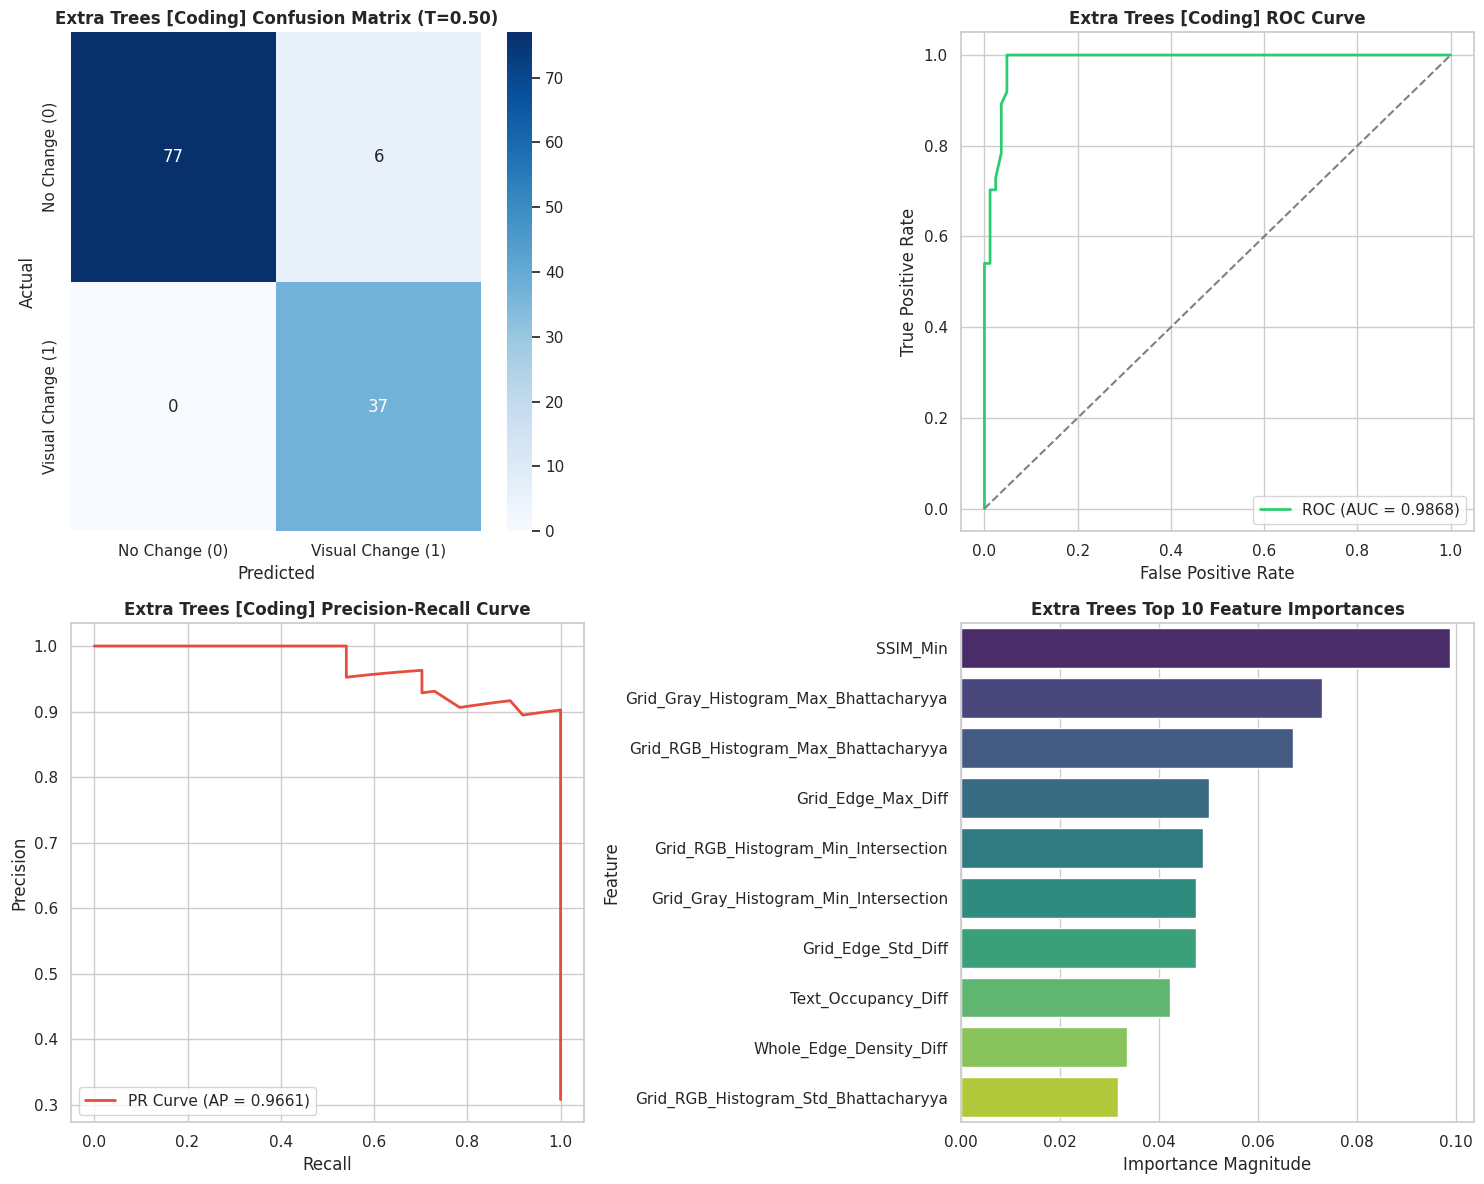

In [34]:
# --- Extra Trees: Evaluation on Domain 1 (Coding Session) ---
metrics_et_coding = evaluate_and_plot_domain(
    pipeline=et_pipeline,
    X_test=X_test_coding,
    y_test=y_test_coding,
    domain_name="Coding",
    model_name="Extra Trees",
    threshold=0.50
)



========================= EXTRA TREES - SLIDES TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     1.0000
                 Precision     1.0000
                    Recall     1.0000
                  F1-Score     1.0000
                   ROC-AUC     1.0000
PR-AUC (Average Precision)     1.0000

--- Classification Report: Extra Trees [Slides] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       1.00      1.00      1.00       147
Visual Change (1)       1.00      1.00      1.00        11

         accuracy                           1.00       158
        macro avg       1.00      1.00      1.00       158
     weighted avg       1.00      1.00      1.00       158



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


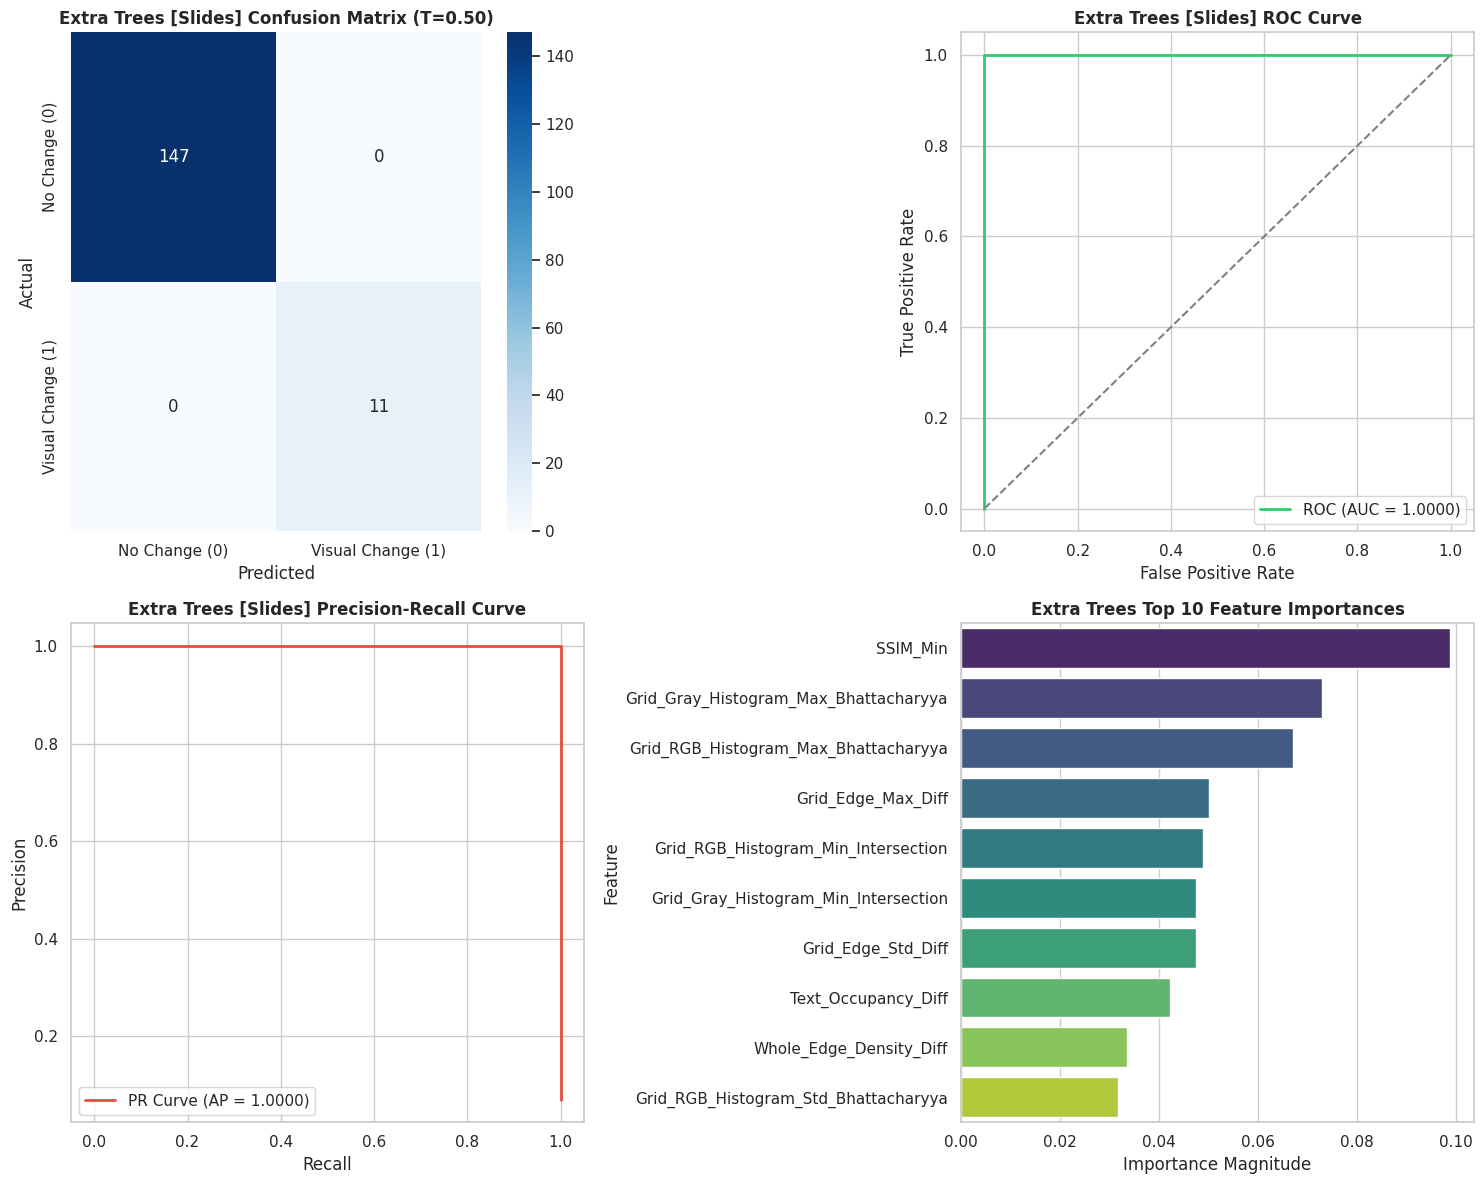

In [35]:
# --- Extra Trees: Evaluation on Domain 2 (Slide Presentation) ---
metrics_et_slides = evaluate_and_plot_domain(
    pipeline=et_pipeline,
    X_test=X_test_slides,
    y_test=y_test_slides,
    domain_name="Slides",
    model_name="Extra Trees",
    threshold=0.50
)



========================= EXTRA TREES - MATH TEST (T=0.50) =========================
                    Metric Test Score
                  Accuracy     0.9259
                 Precision     0.9606
                    Recall     0.9173
                  F1-Score     0.9385
                   ROC-AUC     0.9602
PR-AUC (Average Precision)     0.9631

--- Classification Report: Extra Trees [Math] (T=0.50) ---
                   precision    recall  f1-score   support

    No Change (0)       0.88      0.94      0.91        83
Visual Change (1)       0.96      0.92      0.94       133

         accuracy                           0.93       216
        macro avg       0.92      0.93      0.92       216
     weighted avg       0.93      0.93      0.93       216



/tmp/ipykernel_22220/2318451362.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_imp, ax=axes[1, 1], palette="viridis")


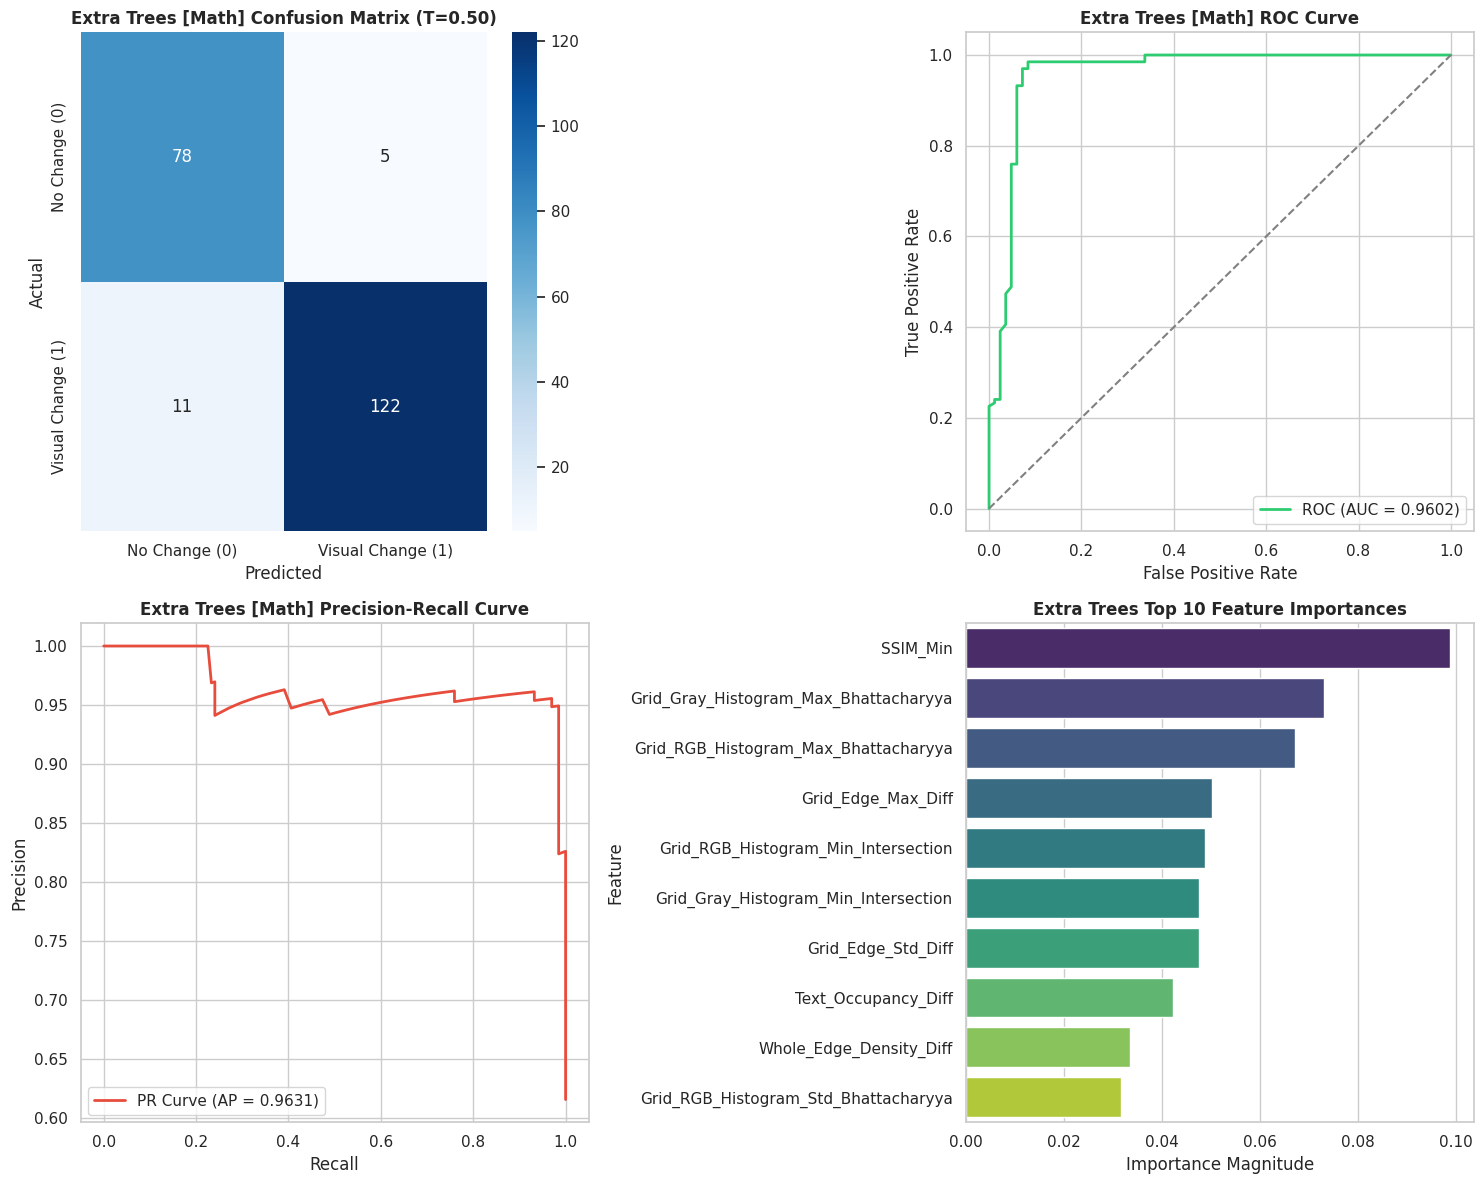

In [36]:
# --- Extra Trees: Evaluation on Domain 3 (Math Lecture) ---
metrics_et_math = evaluate_and_plot_domain(
    pipeline=et_pipeline,
    X_test=X_test_math,
    y_test=y_test_math,
    domain_name="Math",
    model_name="Extra Trees",
    threshold=0.50
)


In [37]:
# --- Extra Trees: Cross-Domain Summary & Export ---
df_et_summary = summarize_domain_metrics([metrics_et_coding, metrics_et_slides, metrics_et_math])
print("================== EXTRA TREES CROSS-DOMAIN SUMMARY ==================")
print(df_et_summary.to_string(index=False))

export_package_et = {
    "model_name": "Extra Trees (Layer 1 - Combined)",
    "pipeline": et_pipeline,
    "feature_columns": feature_cols,
    "cross_domain_metrics": df_et_summary.to_dict(orient="records")
}
joblib.dump(export_package_et, "L1_models/combined_extra_trees.pkl")
print("Saved model package to 'L1_models/combined_extra_trees.pkl'")


================== EXTRA TREES CROSS-DOMAIN SUMMARY ==================
      Model Domain  Threshold  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
Extra Trees Coding        0.5  0.950000   0.860465 1.000000  0.925000 0.986812 0.966050
Extra Trees Slides        0.5  1.000000   1.000000 1.000000  1.000000 1.000000 1.000000
Extra Trees   Math        0.5  0.925926   0.960630 0.917293  0.938462 0.960187 0.963066
Saved model package to 'L1_models/combined_extra_trees.pkl'


## 5. Master Cross-Domain Generalization Benchmark


=================== F1-SCORE ACROSS MODELS & DOMAINS ===================


Domain,Coding,Math,Slides,Macro-Avg F1
Model,,,,
Extra Trees,0.9250,0.9385,1.0000,0.9545
Logistic Regression,0.7347,0.8016,0.3607,0.6323
Random Forest,0.9367,0.9302,0.8800,0.9156
XGBoost,0.9250,0.9141,0.8800,0.9064



=================== ROC-AUC ACROSS MODELS & DOMAINS ===================


Domain,Coding,Math,Slides,Macro-Avg AUC
Model,,,,
Extra Trees,0.9868,0.9602,1.0000,0.9823
Logistic Regression,0.9131,0.8829,1.0000,0.9320
Random Forest,0.9923,0.9616,1.0000,0.9846
XGBoost,0.9945,0.9633,0.9994,0.9857



=================== PR-AUC (AVERAGE PRECISION) ACROSS MODELS & DOMAINS ===================


Domain,Coding,Math,Slides,Macro-Avg PR-AUC
Model,,,,
Extra Trees,0.9661,0.9631,1.0000,0.9764
Logistic Regression,0.8120,0.9258,1.0000,0.9126
Random Forest,0.9801,0.9673,1.0000,0.9825
XGBoost,0.9879,0.9656,0.9924,0.9820


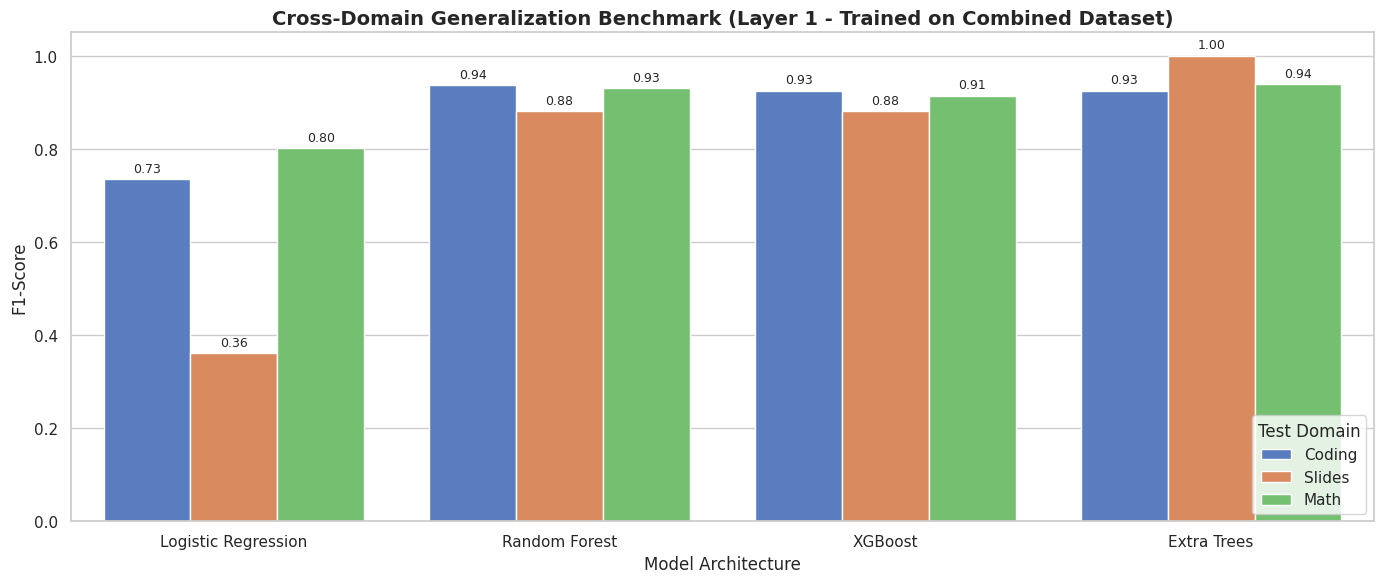

Master benchmark table exported to '/content/cross_domain_benchmark.csv'


In [38]:
# ==============================================================================
# Master Cross-Domain Generalization Benchmark & Comparison
# ==============================================================================
df_master_benchmark = pd.DataFrame(global_benchmark_records)
df_master_benchmark.to_csv("/content/cross_domain_benchmark.csv", index=False)

print("=================== F1-SCORE ACROSS MODELS & DOMAINS ===================")
f1_pivot = df_master_benchmark.pivot(index="Model", columns="Domain", values="F1-Score")
f1_pivot["Macro-Avg F1"] = f1_pivot.mean(axis=1)
display(f1_pivot.round(4))

print("\n=================== ROC-AUC ACROSS MODELS & DOMAINS ===================")
auc_pivot = df_master_benchmark.pivot(index="Model", columns="Domain", values="ROC-AUC")
auc_pivot["Macro-Avg AUC"] = auc_pivot.mean(axis=1)
display(auc_pivot.round(4))

print("\n=================== PR-AUC (AVERAGE PRECISION) ACROSS MODELS & DOMAINS ===================")
pr_pivot = df_master_benchmark.pivot(index="Model", columns="Domain", values="PR-AUC")
pr_pivot["Macro-Avg PR-AUC"] = pr_pivot.mean(axis=1)
display(pr_pivot.round(4))

# Comprehensive Multi-Bar Plot
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_master_benchmark, x="Model", y="F1-Score", hue="Domain", palette="muted", ax=ax)
ax.set_title("Cross-Domain Generalization Benchmark (Layer 1 - Trained on Combined Dataset)", fontsize=14, fontweight="bold")
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_xlabel("Model Architecture", fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(title="Test Domain", loc="lower right")

# Annotate values
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h),
                    ha="center", va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.savefig("cross_domain_generalization_benchmark.png", dpi=300)
plt.show()

print("Master benchmark table exported to '/content/cross_domain_benchmark.csv'")
